# Session 5: Point Spread Function - Image resolution and more
_Script author: g.savini@ucl.ac.uk  28/01/2024_ <br>
_updated: g.savini@ucl.ac.uk  11/02/2026_

Task completed by: Klara Kurucova | 12/02/2026 | PHAS0020

## Abstract 
In this task we will explore fitting a Gausian to a 2D data set from a FITS image taken at the UCL Observatory. By picking an un-saturated source, we will find fit parameters for its Gaussian fit using "scipy.optimize.curve_fit" as we did in tasks in previous weeks. Exploring 3D contour representation, we will subtract our findings from our original data set to see the validity of this method.

In the second part of this task we will then explore Monte Carlo simulations and attempt to find the same fit parameters but this time through an MC simulation. This will be done by evaluating the least squares residuals and exploring its dependance on each fit parameter. Obtaining parameters through this alternative method, we can then compare our results and draw conclusions about the validity of these methods. 

<div class="alert alert-block alert-info">

**This session has a wide range of topics which will require more reading. There will be fewer and shorter tasks to compensate.**

By the end of this session, you will have learned about:
<ul>
<li> Extend the fitting of data to any arbitrary two dimensional function using <tt>scipy.optimize.curve_fit</tt> as in the last task; </li>
<li> Use this to evaluate the point spread function (or psf) of an image and its relation to the telescope and the seeing;</li>
<li> Fit and recover the Point-Spread-Function of an image. </li>
<li> Perform a basic Montecarlo as a way of finding the parameters and their distribution in fitting an observable. </li>
</ul>
</div>
<div class="alert alert-success"> 

### Part 1 Array manipulation ###

As always let us import the same set of modules that we are likely to need (you can always come back to this cell and add more and re-run the Kernel if you need to).

</div>

In [1]:
# Pre-filled Cell 
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats
from scipy import optimize
import os
import random

#To introduce a range of 3D plots, we need to import another library
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# The following line makes the images a bit larger than default - works better on a large screen
plt.rcParams['figure.figsize'] = 10,10

### What is a Point Spread Function and why is it relevant to astronomy ###
<div class="alert alert-success"> 
Details on PSFs and how they relate to astronomy and astronomical instrumentation can be found in almost every text of observational astronomy. You can find some additional information on:

D. Scott Birney, G. Gonzalez, D. Oesper, Observational Astronomy (2nd edition), ISBN 0 521
853705 (Cambridge University Press, 2006) – Also available online at UCL-Explore

or

F. Chromey, To Measure the Sky: An Introduction to Observational Astronomy (2nd Edition),
ISBN: 978-1-107-572560 (Cambridge University Press, 2016). ) – Also available online at UCLExplore

But the single best definition that can suit our initial purpose can be borrowed by <a href='https://en.wikipedia.org/wiki/Point_spread_function'> Wikipedia </a> and is:

<em>"The point spread function (PSF) describes the response of an imaging system to a point source or point object."</em>

We will get to the details of how the psf is generated, but for now let us look at this from an empirical point and simply observe how the response to a point source (in our case a star- which is as "point-like" as it gets) is often dominated by the <a href='https://en.wikipedia.org/wiki/Astronomical_seeing#The_full_width_at_half_maximum_(FWHM)_of_the_seeing_disc'>astronomical "seeing"</a> of the site rather than from instrumental features.

For now, we are interested in the final seeing disc that is obtained in an image.

As such let us consider a small portion of an image taken at UCLO where we have isolated a relatively bright star.

### Part 1 - Finding the PSF/seeing of a given image ###

While it is more common to talk about PSF in relation to a given instrument (as the Fourier Transform of the telescope aperture), many ground based telescopes have a psf which is dominated by "seeing". As the seeing is itself dependent on atmospheric conditions, it is not a constant of a given system or telescope and therefore cannot be singularly identified for such system but can be referred to a given image.
</div>
<div class="alert alert-block alert-info">
Part A:
    <ol>
        <li> As we did last time, first read through the entire script instructions, try and understand the purpose and the steps taken in this script and then come back at the top and write a 1 or 2 paragraph markdown cell abstract of what this task aims to do.</li>
        <li> Write a markdown cell with the analytical expression (in LaTeX) of the most generic <a href="https://en.wikipedia.org/wiki/Gaussian_function">gaussian</a> possible (elliptical not circularly symmetric and rotated with respect to the xOy reference frame. Include an offset. </li>
        <li> Now define a function that will create such a generic surface given the relevant parameters</li>
        <li> Test its output with a 3D visualization of a 2D dataset of your choice (contour or surface plot). Make sure it is a fully detailed plot which shows the successful creation of the function and label <u>on the figure</u> the various parameters which are relevant to the gaussian</li>
    </ol>
</div>


## Working with generic gaussians

To start our task we will create a function that will create a generic 2D gaussian with elliptical symmetry, which is as follows [1]:
$$
f(x,y) = A* \exp (- (a(x-x_0)^2 + 2b(x-x_0)(y-y_0) + c (y-y_0)^2)
$$

Where the values of the coeffs a,b,c are given by:
- $a = \frac{\cos^2 \theta}{2\sigma_x^2} + \frac{\sin^2 \theta}{2\sigma_y^2}$
- $b = -\frac{\sin \theta \cos \theta}{2\sigma_x^2} + \frac{\sin \theta \cos \theta}{2\sigma_y^2}$
- $c = c = \frac{\sin^2 \theta}{2\sigma_x^2} + \frac{\cos^2 \theta}{2\sigma_y^2}$

Where:
- A is the amplitude
- $x_0$ and $y_0$ are the center
- $\sigma_X$ is the spread of in the x-direction
- $\sigma_y$ is the spread of in the y-direction
- $\theta$ is the rotation value

In [6]:
def gauss_2d_generic(X, Y, mux, muy, sigmax, sigmay, amplitude, offset, rotation):
    """
    This function creates a 2D Gaussian elliptical fit based on input parameters of the user

    Input:
    - x = 2 x 10000 array
    - mux = center point in x
    - muy = center point in y
    - sigmax = sigma in x direction
    - sigmay = sigma in y direction
    - amplitude maximum
    - offset of the data
    - rotation 

    Output:
    - GG = a 2D elliptical Gaussian fit
    """
    a = np.cos(rotation)**2 / (2 * sigmax**2) + np.sin(rotation)**2 / (2 * sigmay**2);
    b = np.sin(2 * rotation) / (4 * sigmax**2) - np.sin(2 * rotation) / (4 * sigmay**2);
    c = np.sin(rotation)**2 / (2 * sigmax**2) + np.cos(rotation)**2 / (2 * sigmay**2);
    
    gauss = amplitude * np.exp(-(a * (X - mux)**2 + 2 * b * (X - mux) * (Y - muy) + c * (Y - muy)**2)) + offset
    return gauss

In [8]:
# STUDENT GENERATED CELL #
# Create the 2D arrays for x and y and test the Gaussian function as we did 
# last week (later we will refer to these as "xx" and "yy")


#code from week 4 task
size=100

# The following creates a size^2 array from "0" to "size" and then rearranges it 
# so its counting along columns and then up 1 row at a time
temp  = np.linspace(0,(size*size-1.)/size,size*size)

# We then use the "reshape" command to rearrange this long 1D array of values to make a square array
temp2 = np.reshape(temp,(size,size))

# Now we use the raster scan array obtained to create two arrays which are respectively the "x" and the "y" of 
# any 2D square image we want with "size" as its side.

yy = np.floor(temp2)     # floor truncates the array (as pixel values are integers)
temp3 = (temp2-yy)*size
xx = np.round(temp3)



In [10]:
created_array1 = gauss_2d_generic(xx, yy, 50, 50, 5, 10, 1, 2, 0.5)

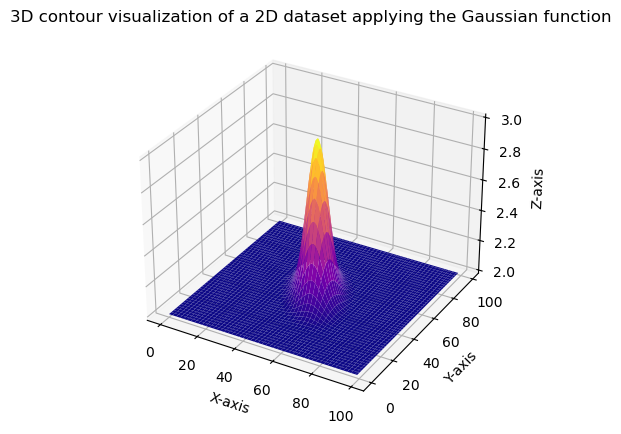

In [12]:
# EXAMPLE PLOTS CELL 

#contour plot 
fig = plt.figure(figsize =(5, 5))
ax = plt.axes(projection ='3d')
ax.plot_surface(xx, yy, created_array1, cmap=cm.plasma)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('3D contour visualization of a 2D dataset applying the Gaussian function')
plt.show()



## Fitting a Gaussian to a chosen source

<div class="alert alert-success"> 
  
<b> Task Set B.1: </b> 
<ol>
    <li> Now load the image provided.
    <li> Select a region of side=100 around what you think is a star (not too close to the edge of the image) and show this subset of the image. Tip: Try and center the star at the center of the subset - not necessary, but helps. Also make sure it is not a saturated star... this can be checked by counts but also by looking at the shape in 3D (avoid flat tops!).
        Also remember that when visualised  the X and Y are inverted in graphical output (i.e. F(Y,X) if you want X horizontal and Y vertical)
    </ol>
</div>

In [16]:
# STUDENT GENERATED CELL #
from astropy.io import fits

#load the image 
home_dir = os.getcwd()+'/'
print ("The Home Directory is set to:", home_dir) 
image= fits.open(f"{home_dir}s5_test_image.fits")[0]
fits_image = image.data



The Home Directory is set to: /Users/klarakurucova/Desktop/UCL /Practical astrophysics and computing /week 5/


In [18]:
#run some stats
def quick_look (image):
    """
    This function runs some basic stats one our FITS image and returns appropriate vmin & vmax
    Input:
    fits image
    
    Output:
    mean, standard deviation, vmin, vmax
    """
    mean_image = np.mean(fits_image)
    std_image = np.std(fits_image)
    vmin_image = mean_image - 3 * std_image
    vmax_image = mean_image + 20 * std_image
    print (f"The mean of the FITS image is {mean_image}")
    print (f"The standard deviation of the FITS image is {std_image}")
    print (f"The vmin of the FITS image is {vmin_image}")
    print (f"The vmax of the FITS image is {vmax_image}")
    

    return mean_image, std_image, vmin_image, vmax_image

In [20]:
#run quick look
mean, std, vmin, vmax = quick_look(fits_image)


The mean of the FITS image is 3962.71728515625
The standard deviation of the FITS image is 699.1085205078125
The vmin of the FITS image is 1865.3917236328125
The vmax of the FITS image is 17944.8876953125


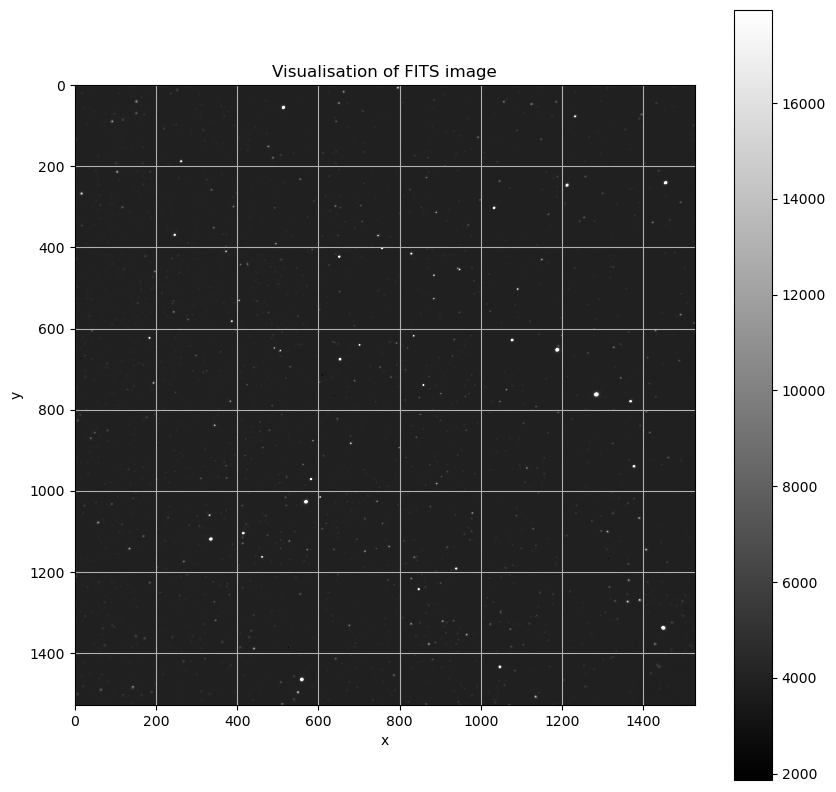

In [22]:
def show_image (image_data, vmin_image, vmax_image):
    """This function visualises a FITS image with an appropriate floor and ceiling values
    Input:
    image_data = a FITS image converted to data
    
    Output:
    Matplotlib visualisation of the image"""
    
    #show based on stats
    plt.figure ()
    plt.imshow(image_data, cmap='gray', vmin=vmin_image, vmax=vmax_image)
    plt.title ('Visualisation of FITS image')
    plt.xlabel('x')
    plt.ylabel ('y')
    plt.colorbar()
    plt.grid()
    plt.show()
    return 

show_image (fits_image, vmin, vmax)


In [24]:
#finding max for the entire image
np.max(fits_image)

71252.52

Let us noe select a slice containing our chosen star:

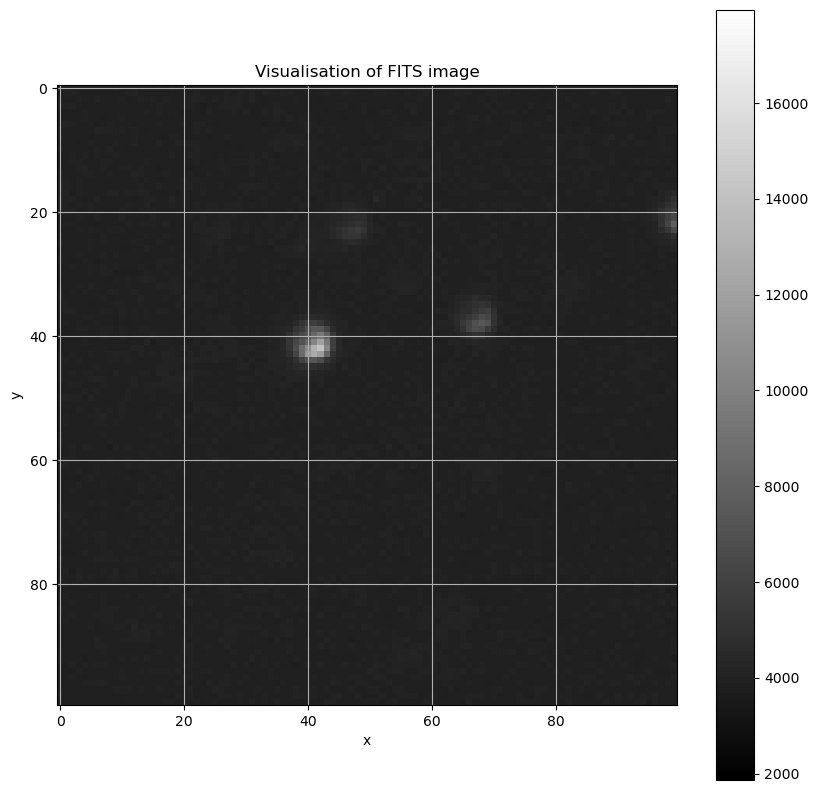

In [27]:
### STUDENT GENERATED CELL ###

#select portion around the star
star_section = fits_image [50:150, 50:150] #y coord first

#plot
show_image (star_section, vmin, vmax)


In [29]:
# checking if the star is saturated 
max_star = np.max (star_section)
print(f"The ADU of the star is {max_star}")

The ADU of the star is 14178.576171875


Hence we conclude that the read out noise for this star is small enough to conclude that it is not saturated and hence can will proceed with this target in the rest of the task.

<div class="alert alert-success"> 
  
<b> Task Set B.2: </b> 
<ul>
    <li> To perform a 2D fit we will still use the generic "function-fitter" tool we used in python. But to do so we need to flatten our array (as we have done before). There is more than one way to do this.
        </ul>
</div>
<div class="alert alert-info"> 
   
Consider checking the difference between using:
<tt> ndarray.flat </tt>
<tt> ndarray.flatten </tt>
<tt> ndarray.reshape </tt>
and
<tt> np.ravel </tt>

In the next cell, we will define for you two arrays (1 x 100) (effectively the x and y axes of your previous 2D arrays).
    
</div>

In [33]:
# Prefilled Cell for you #

#In the next line we create a 2xN array from the previous definition of 2D x and y arrays:
#In this 2 x 10000 array there is a correspondence of 2 (x,y) coordinates for each of the 10000 points (100^2)
xy1d = np.vstack((xx.ravel(), yy.ravel()))   # Coordinates corresponding to the unpacked data.

#The following is the unpacked image (so the "z" points or the values of the image in a 1 x 10000 array)
unp_subset = star_section.ravel()                        # Unpacked data (1xN^2)

print(np.shape(xy1d),np.shape(unp_subset)) 

(2, 10000) (10000,)


<div class="alert alert-success"> 
<ul>
    <li> Modify the following function below (completing the parts which are left blank according to your previously defined function of the generic gaussian).

</ul>
</div>

Elliptical gaussian that we will use is the same as in the previous section and will be used below to properly estimate the fit parameters using "optimize.curve.fit":

In [37]:
# STUDENT MODIFIED CELL #

# Uncomment and fill the empty expression for GG to return an unravelled gaussian.
# Use "X" and "Y" for the expression of coordinates of the 2D gaussian.
# Make use of temporary variables to simplify calculations and avoid mistakes rather than one huge equation

def Gauss2D(x, mux, muy, sigmax, sigmay, amplitude, offset, rotation):
    """
    This function creates a 2D Gaussian elliptical fit based on input parameters of the user

    Input:
    - x = 2 x 10000 array
    - mux = center point in x
    - muy = center point in y
    - sigmax = sigma in x direction
    - sigmay = sigma in y direction
    - amplitude maximum
    - offset of the data
    - rotation 

    Output:
    - GG = a 2D elliptical Gaussian fit
    """
    assert len(x) == 2
    X = x[0]
    Y = x[1]
    a = np.cos(rotation)**2 / (2 * sigmax**2) + np.sin(rotation)**2 / (2 * sigmay**2);
    b = np.sin(2 * rotation) / (4 * sigmax**2) - np.sin(2 * rotation) / (4 * sigmay**2);
    c = np.sin(rotation)**2 / (2 * sigmax**2) + np.cos(rotation)**2 / (2 * sigmay**2);
    
    GG = amplitude * np.exp(-(a * (X - mux)**2 + 2 * b * (X - mux) * (Y - muy) + c * (Y - muy)**2)) + offset
    return GG.ravel()

#Let us invoke the "optimize.curve.fit" function which requires us to call in order:
#
# -) The name of the function to be used (returning the 1D folded curve)
# -) The values of the x,y pair array 
# -) The values of the image array to fit
# -) An array containing the initial guesses for the various parameters used

# You can make a stab (as you have inspected the image and positioned the star in the subset) at these guesses

#guesses of parameters of a Gaussian fit
po = np.asarray([40, 42, 5, 5, 14178.576, np.mean(star_section), 0.1], dtype=float) #Build the array of parameters for initial guess

#Similar to previous cases, the fit parameters and covariant matrix are returned next:
#Notice: fitting many parameters can cause frequent errors if we are away from a "good" guess or if we leave
#parameters free to take "any" value... so if known, sensible boundary conditions in the form of 2 tuples can be added.

#fitting to find Gaussian fit parameters
popt,pcov = optimize.curve_fit(Gauss2D, xy1d, unp_subset, po) 

#Use our generic 2D gaussian fit and fit the data.

#To create the gaussian as a result of the fit, we need to simply use the same function above with our 
#fit parameters as input:
z_fit_1d = Gauss2D(xy1d, *popt)              # Create the unpacked fit

#and reshape the array to make it 2D
Z_fit = z_fit_1d.reshape(size,size)            # Reshape it as the original NxN



We can justify our "guesses" for the gaussian fit coefficients. The x center & y center were taken from the subplot showing the zoomed in star. The chosen sigma values were estimated. The amplitude was taken as the max ADU counts in the star image slice, under the assumption that the brightest pixel is at the center of the star. Our offset was taken as the mean of the data set, and the rotation was set to a small, but non-zero value in order to provide the "optimize.curve_fit" with at least some input. 

<div class="alert alert-success"> 
  
<b> Task Set B(4): </b> 
<ul>
    <li> Print the optimized parameters (once you get a good fit) with uncertainties.
    <li> Show side by side the subset image and the fitted gaussian
</ul>
</div>

In [41]:
### STUDENT GENERATED CELL ###

#unpack values
m0x_fit, m0y_fit, sigmax_fit, sigmay_fit, amplitude_fit, offset_fit, rotation_fit = popt 

#unpack errors
m0x_err, m0y_err, sigmax_err, sigmay_err, amplitude_err, offset_err, rotation_err = np.sqrt(np.diag(pcov))

#print results 
print (f"The x-centre of the fit is {m0x_fit:.3f} ± {m0x_err:.3f}")
print (f"The y-centre of the fit is {m0y_fit:.3f} ± {m0y_err:.3f}")
print (f"The sigma X of the fit is {sigmax_fit:.3f} ± {sigmax_err:.3f}")
print (f"The sigma Y of the fit is {sigmay_fit:.3f} ± {sigmay_err:.3f}")
print (f"The amplitude of the fit is {amplitude_fit:.3f} ± {amplitude_err:.3f}")
print (f"The off-set of the fit is {offset_fit:.3f} ± {offset_err:.3f}")
print (f"The rotation of the fit is {rotation_fit:.3f} ± { rotation_err:.3f}")


The x-centre of the fit is 41.198 ± 0.014
The y-centre of the fit is 41.799 ± 0.014
The sigma X of the fit is 1.645 ± 0.013
The sigma Y of the fit is 1.912 ± 0.015
The amplitude of the fit is 9228.920 ± 71.885
The off-set of the fit is 3983.369 ± 1.604
The rotation of the fit is -79519.068 ± 0.036


Let us briefly comment on our obtained values. The x-center and y-center values correspond to our estimated values. We see that our estimates for sigma were unnecessarily large and so was our amplitude, while our offset was chosen suitably. Our value for rotation seems rather unusual, nevertheless even upon changing our guess parameters multiple times the estimate for this parameter did not change. Let us now plot our gaussian fit estimates side by side to our chosen image to see how well our parameter estimation did. 

Text(0, 0.5, 'Y-axis')

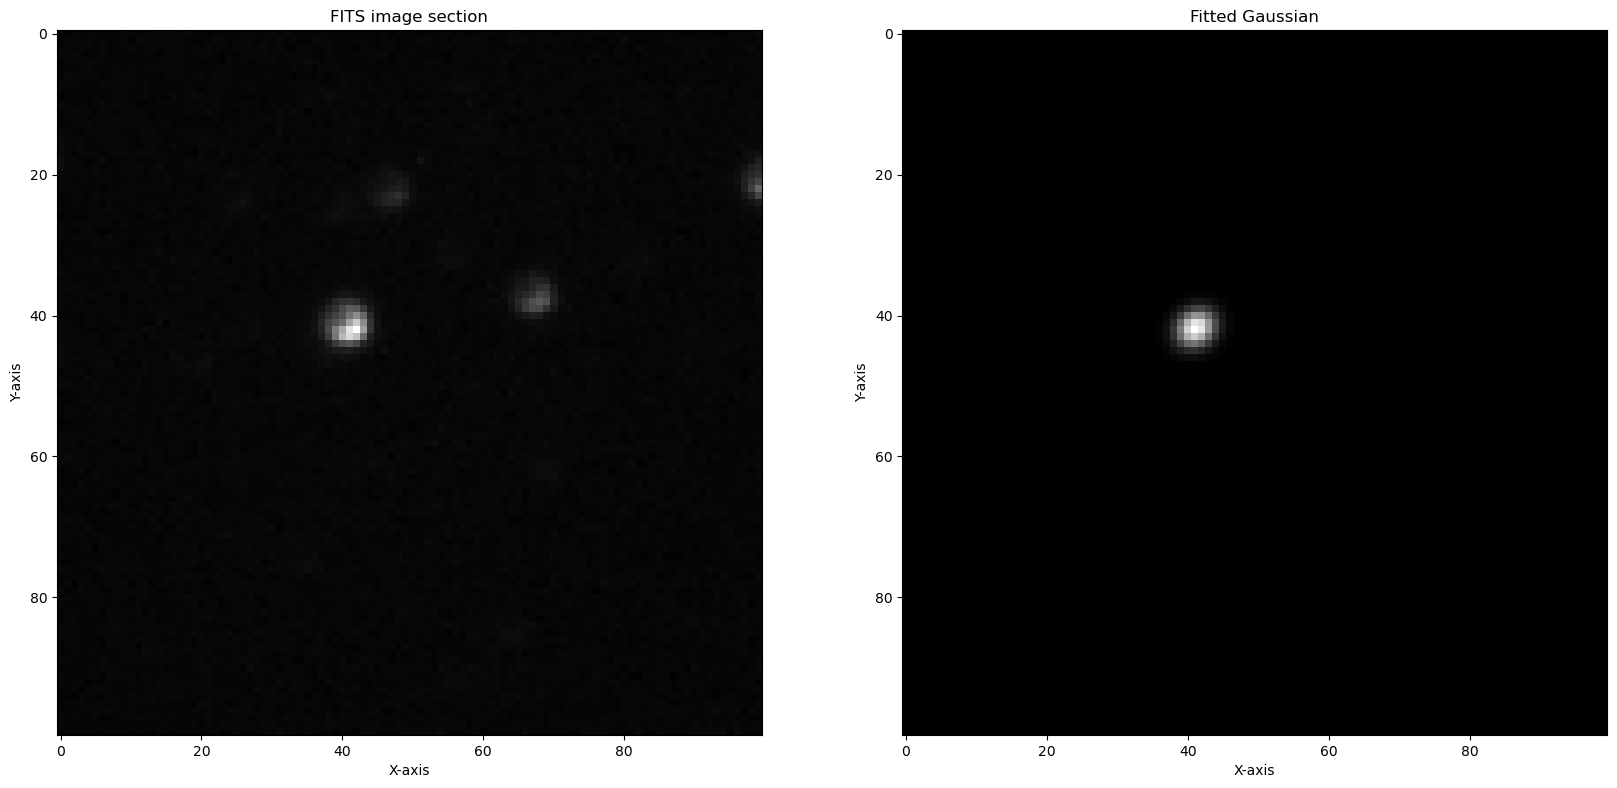

In [44]:
### STUDENT GENERATED CELL ###

figure, axis = plt.subplots(1,2, figsize=(20,10))

#fits image
axis[0].imshow (star_section, cmap = 'grey')
axis[0].set_title ("FITS image section")
axis[0].set_xlabel('X-axis')
axis[0].set_ylabel('Y-axis')

#gauss
axis[1].imshow (Z_fit, cmap = 'grey')
axis[1].set_title ("Fitted Gaussian")
axis[1].set_xlabel('X-axis')
axis[1].set_ylabel('Y-axis')

We see that our Gaussian fits well as the gaussina is plotted in the same area as the star. Although the star has a less uniform brightness than the Gaussian fit, it seems as a good approximation for this point. We shall see if this will impact our results later in the task. We can also subtract the two to see if the Gaussian does indeed map the star signal correctly:

Text(0, 0.5, 'Y-axis')

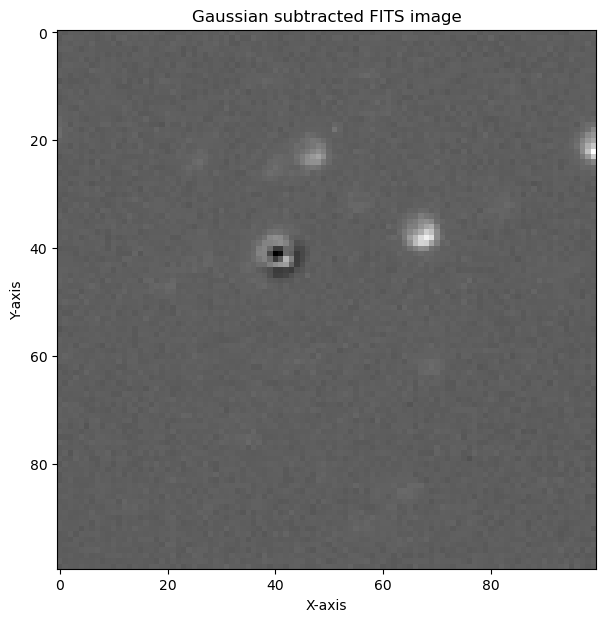

In [51]:
#subtracted fits image
plt.figure (figsize=(10,7))
plt.imshow (star_section - Z_fit, cmap = 'grey')
plt.title ("Gaussian subtracted FITS image")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')


We see a "hole" where we expected the star to reside hence we can conlcude the Gaussian to be fitting the image of the star well.

<div class="alert alert-success"> 

<b> Task Set B(6): </b> 
If the fit looks good, create a set of 2 plots where you compare surface and contour plots for the image and the relevant gaussian fit.
</div>

Text(0.5, 0, 'Z-axis')

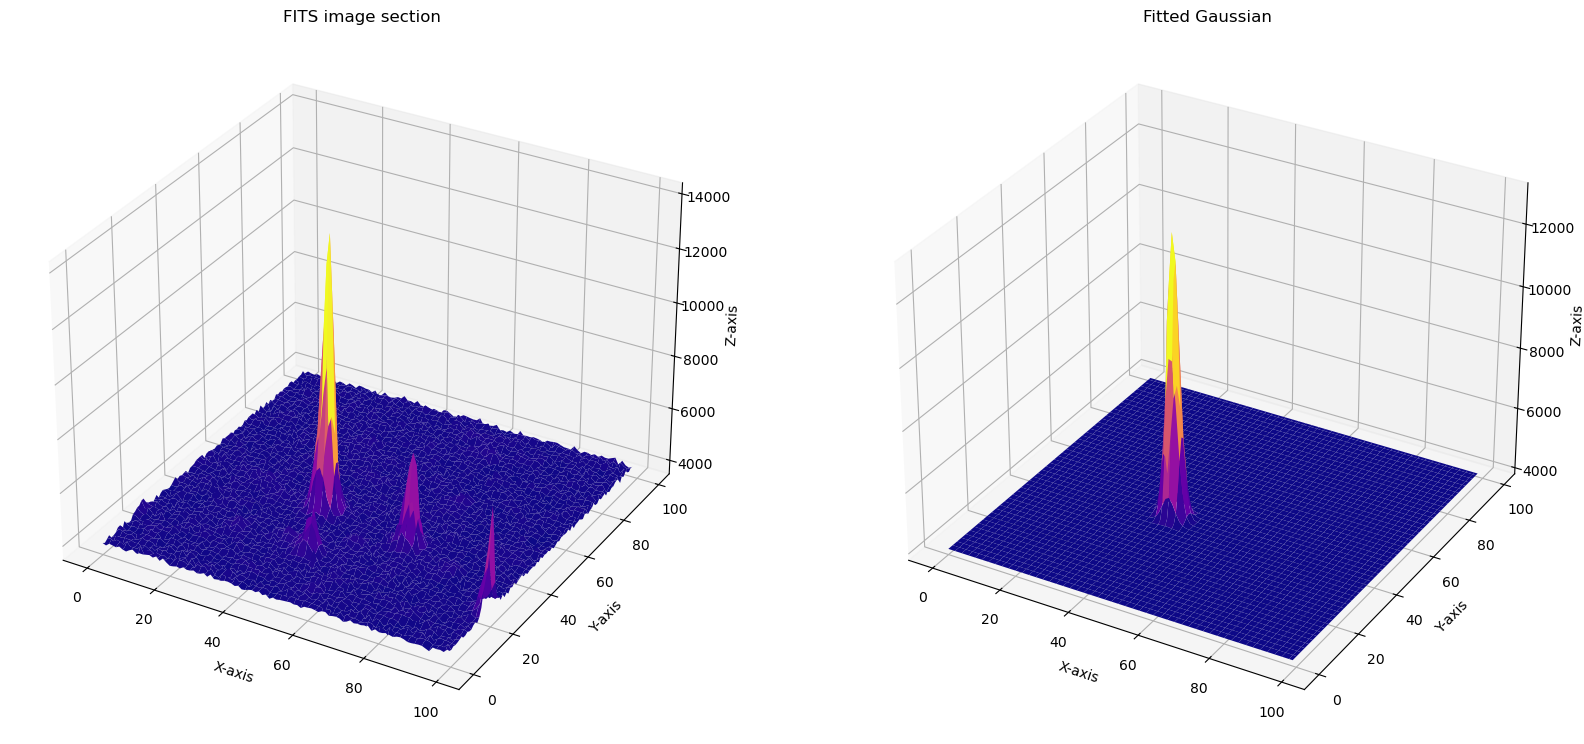

In [55]:
#creating contour plots 
figure, axis = plt.subplots(1,2, figsize=(20,10), subplot_kw={"projection": "3d"})

#fits image
axis[0].plot_surface (xx, yy, star_section, cmap=cm.plasma)
axis[0].set_title ("FITS image section")
axis[0].set_xlabel('X-axis')
axis[0].set_ylabel('Y-axis')
axis[0].set_zlabel('Z-axis')

#gauss
axis[1].plot_surface (xx, yy, Z_fit, cmap=cm.plasma)
axis[1].set_title ("Fitted Gaussian")
axis[1].set_xlabel('X-axis')
axis[1].set_ylabel('Y-axis')
axis[1].set_zlabel('Z-axis')



It appears that our Gaussian fit appropriately describes our chosen source since we only encounter one sharp peak in its 3D contour plot, while there are a couple of smaller peaks in our FITS image slice.

<div class="alert alert-success"> 

<b> Task Set B(7): </b> 
Zoom in to the star and create a overlapping contour plot of the model to the image of the dataset.</div>

In [60]:
### STUDENT GENERATED CELL ###

#run some quick stats
mean, std, vmin, vmax = quick_look(star_section)

The mean of the FITS image is 3962.71728515625
The standard deviation of the FITS image is 699.1085205078125
The vmin of the FITS image is 1865.3917236328125
The vmax of the FITS image is 17944.8876953125


Text(0, 0.5, 'Y')

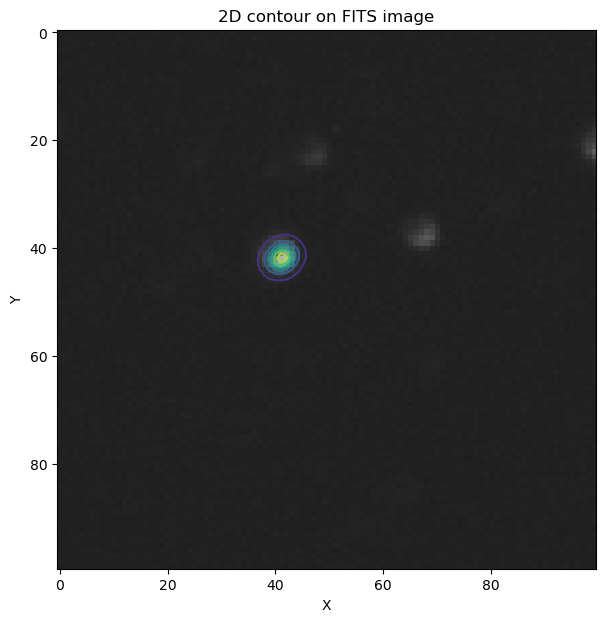

In [62]:
#plot the contour
plt.figure(figsize=(14,7))
plt.imshow(star_section, cmap = 'gray', vmin = 1865, vmax = 17944 )
plt.contour(xx, yy, Z_fit, origin = 'lower')
plt.title ("2D contour on FITS image")
plt.xlabel("X")
plt.ylabel ("Y")

Now let us also plot a 3D contour plot in which we will subtract our Gaussian fit from our image slice containing the star. If all goes well we should obtain a contour plot without the central peak.

Text(0.5, 0, 'Z-axis')

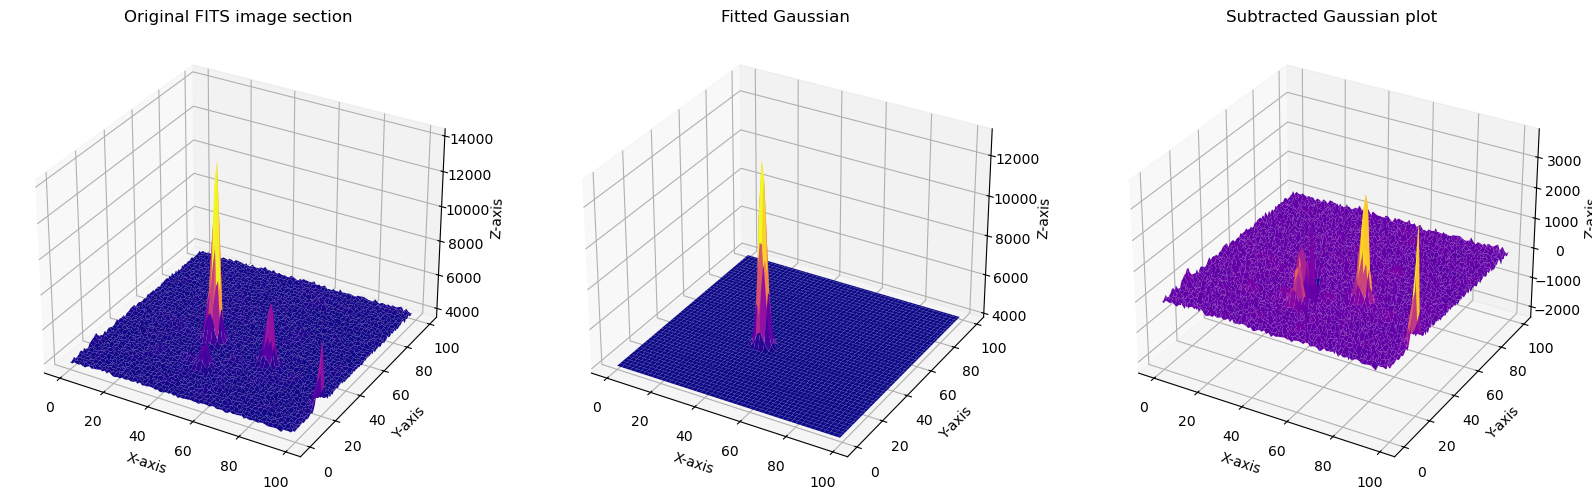

In [65]:
#subtracting the contours
z_subtracted = star_section - Z_fit 

#creating contour plots 
figure, axis = plt.subplots(1,3, figsize=(20,10), subplot_kw={"projection": "3d"})

#fits image
axis[0].plot_surface (xx, yy, star_section, cmap=cm.plasma)
axis[0].set_title ("Original FITS image section")
axis[0].set_xlabel('X-axis')
axis[0].set_ylabel('Y-axis')
axis[0].set_zlabel('Z-axis')

#gauss
axis[1].plot_surface (xx, yy, Z_fit, cmap=cm.plasma)
axis[1].set_title ("Fitted Gaussian")
axis[1].set_xlabel('X-axis')
axis[1].set_ylabel('Y-axis')
axis[1].set_zlabel('Z-axis')

#subtracted
axis[2].plot_surface (xx, yy, z_subtracted, cmap=cm.plasma)
axis[2].set_title ("Subtracted Gaussian plot")
axis[2].set_xlabel('X-axis')
axis[2].set_ylabel('Y-axis')
axis[2].set_zlabel('Z-axis')



By subtracting the Gaussian from our original image, we have sucessfully eliminated the signal from the star. Without this large central peak we can now examine our noise coming from other pixels. As we see three smaller peaks we can infer that these come from the three fainter and smaller stars in our chosen section of the image. We also observe some features of sky background and noise, which could be better studied if we also fit a Gaussian fit to the three fainter sources and removed them too. This is however beyond the scope of this task. 

<div class="alert alert-success">
What we have done, is to find the best fitting gaussian (and offset) to this particular star.


<b> B(8): </b> Question (Answer): Now that you have a function that fully describes (and arguably fits) the photons originating from the star of interest, how could you perform an alternative photometry without using the same techniques used last week? If you can think of such a way, show the value you'd obtain.
        
</div>

What we do in this task is the alternative to aperture photometry since the fit directly quantifies the offset value. We can now run our gaussian function, subtract the offset and integrate it to find the area under the curve which will represent the flux, as an alternative means to aperture photometry. To find a normalised gaussian PSF:
$$
f(x,y) =\frac{1}{2\pi\sigma_X\sigma_Y} f_{gauss}
$$


In [70]:
### STUDENT CODE CELL ###

#call previous function 
gauss_phot = Gauss2D(xy1d, m0x_fit, m0y_fit, sigmax_fit, sigmay_fit, amplitude_fit, 0, rotation_fit)
normalised = gauss_phot / (2*np.pi*sigmax_fit*sigmay_fit)
np.sum(normalised)


9228.919514277515

Which agrees with our obtained value of amplitude for the gaussian fit, demonstarting that this would be a valid method for aperture photometry. The effectivity of this method for conducting aperture photometery on a large number of sources is in question, and hence it is more likely for users to stick to methods such as DAOStar finder in the library Photutils or others.

## Monte Carlo simulations 

<div class="alert alert-success">

<b> Task Set C.1: </b> 
Let us now attempt this in a way that makes us "free" from the auto-fitting of scipy (which we have little control over).
We can do this by illustrating a very basic montecarlo process.

With the previous fit we already know a good set of parameters arguably that will do a good job of fitting (presumably). So we will try this process of creating a loop where we pretend to not know what the actual best fitting values are, but rather suggest that we have a vague idea of what they might be. A process we go through anyway when having to make the initial guess for the scipy.optimize.fit
<ul><li> To do this we will use the same unsaturated star and the same gaussian function. Create a loop with a contained number of iterations (say 100 for a speedy return). In this loop, for each iteration redefine each of the parameters needed in the gaussian by setting its value through a random process with a given distribution.
As we had previously performed a fit, we can "cheat" by setting the range of our distribution around our guesses.
So the two center coordinates can be recalculated in the range:
$$ x_i = [ x_f-dx_f , x_f+dx_f ] \ \ y_i = [ y_f-dy_f , y_f+dy_f ] $$
where you have picked the half range of each of these intervals to be between a quarter to a half of the size of the star.<br>
Do the same with the sigmas of the gaussian. 
With the amplitude and offset, you can for now just take the values from the fit and define the range as something between 80% and 120% of those values, considering that these are easy to estimate from the image, the second being the value of the background around the star and the first the difference between star peak and background.

<li> In each loop ask it to create a random value in that range with a uniform distribution. This can be done using <code> random.uniform(low=0.0, high=1.0, size=None)</code> where you can put your own low and high values as well as defining the size of the array requested - None producing a single number.
<li> With this set of parameters, create the gaussian using your function on a similar sized subset array.
<li> Finally, calculate the total sum of the squared residuals obtained by subtracting the gaussian from the image subset.
<li> Store the value of each parameter in a predefined array for that parameter as well as the sum of the LSR calculated. You can later substitute this with a chi-square once we have a value for the noise of each pixel.
</ul>
        
</div>

Let us run an initially MC simulation to explore how each paramater of our Gaussian fit infuences the least square residuals (LSR). This will be done by randmoly varrying each fit parameter based on the instrucions stated above, applying it to a gaussian fit and finding the LSR by:
$$
LSR = \sum (image - gauss)^2
$$

In [76]:
### STUDENT CODE CELL ###

#monte carlo simulations
n = 100000

#define empty arrays
mux_mc =np.array([])
muy_mc = np.array([])
sigmax_mc = np.array([])
sigmay_mc = np.array([])
amplitude_mc = np.array([])
offset_mc = np.array([])
rotation_mc = np.array ([])
LSR_mc = np.array ([])

#loop
for x in range (n):
    mux_run = random.uniform(m0x_fit - 3, m0x_fit + 3)
    muy_run = random.uniform(m0y_fit - 3, m0y_fit + 3)
    sigmax_run = random.uniform(sigmax_fit - 0.5, sigmax_fit + 0.5)
    sigmay_run = random.uniform(sigmay_fit - 0.5, sigmay_fit + 0.5)
    amplitude_run = random.uniform(0.8 * amplitude_fit, 1.2* amplitude_fit) 
    offset_run = random.uniform(0.8 * offset_fit, 1.2* offset_fit) 
    rotation_run = random.uniform(0.8 * rotation_fit, 1.2* rotation_fit) 

    #gaussian
    mc_gauss = Gauss2D(xy1d, mux_run, muy_run, sigmax_run, sigmay_run, amplitude_run, offset_run, rotation_run)

    #lSR
    LSR_run =np.sum((unp_subset - mc_gauss)**2)
    
    #append
    mux_mc = np.append(mux_mc, mux_run)
    muy_mc = np.append(muy_mc, muy_run)
    sigmax_mc = np.append(sigmax_mc, sigmax_run)
    sigmay_mc = np.append(sigmay_mc, sigmay_run)
    amplitude_mc =np.append(amplitude_mc, amplitude_run)
    offset_mc = np.append (offset_mc, offset_run)
    rotation_mc = np.append (rotation_mc, rotation_run)
    LSR_mc = np.append (LSR_mc, LSR_run)



<div class="alert alert-success">
Once you have run the cell above, create a set of plots (a multiplot) where you show the values of the LSR as a function of each parameter separately.
</div>

Text(0, 0.5, 'log (LSR)')

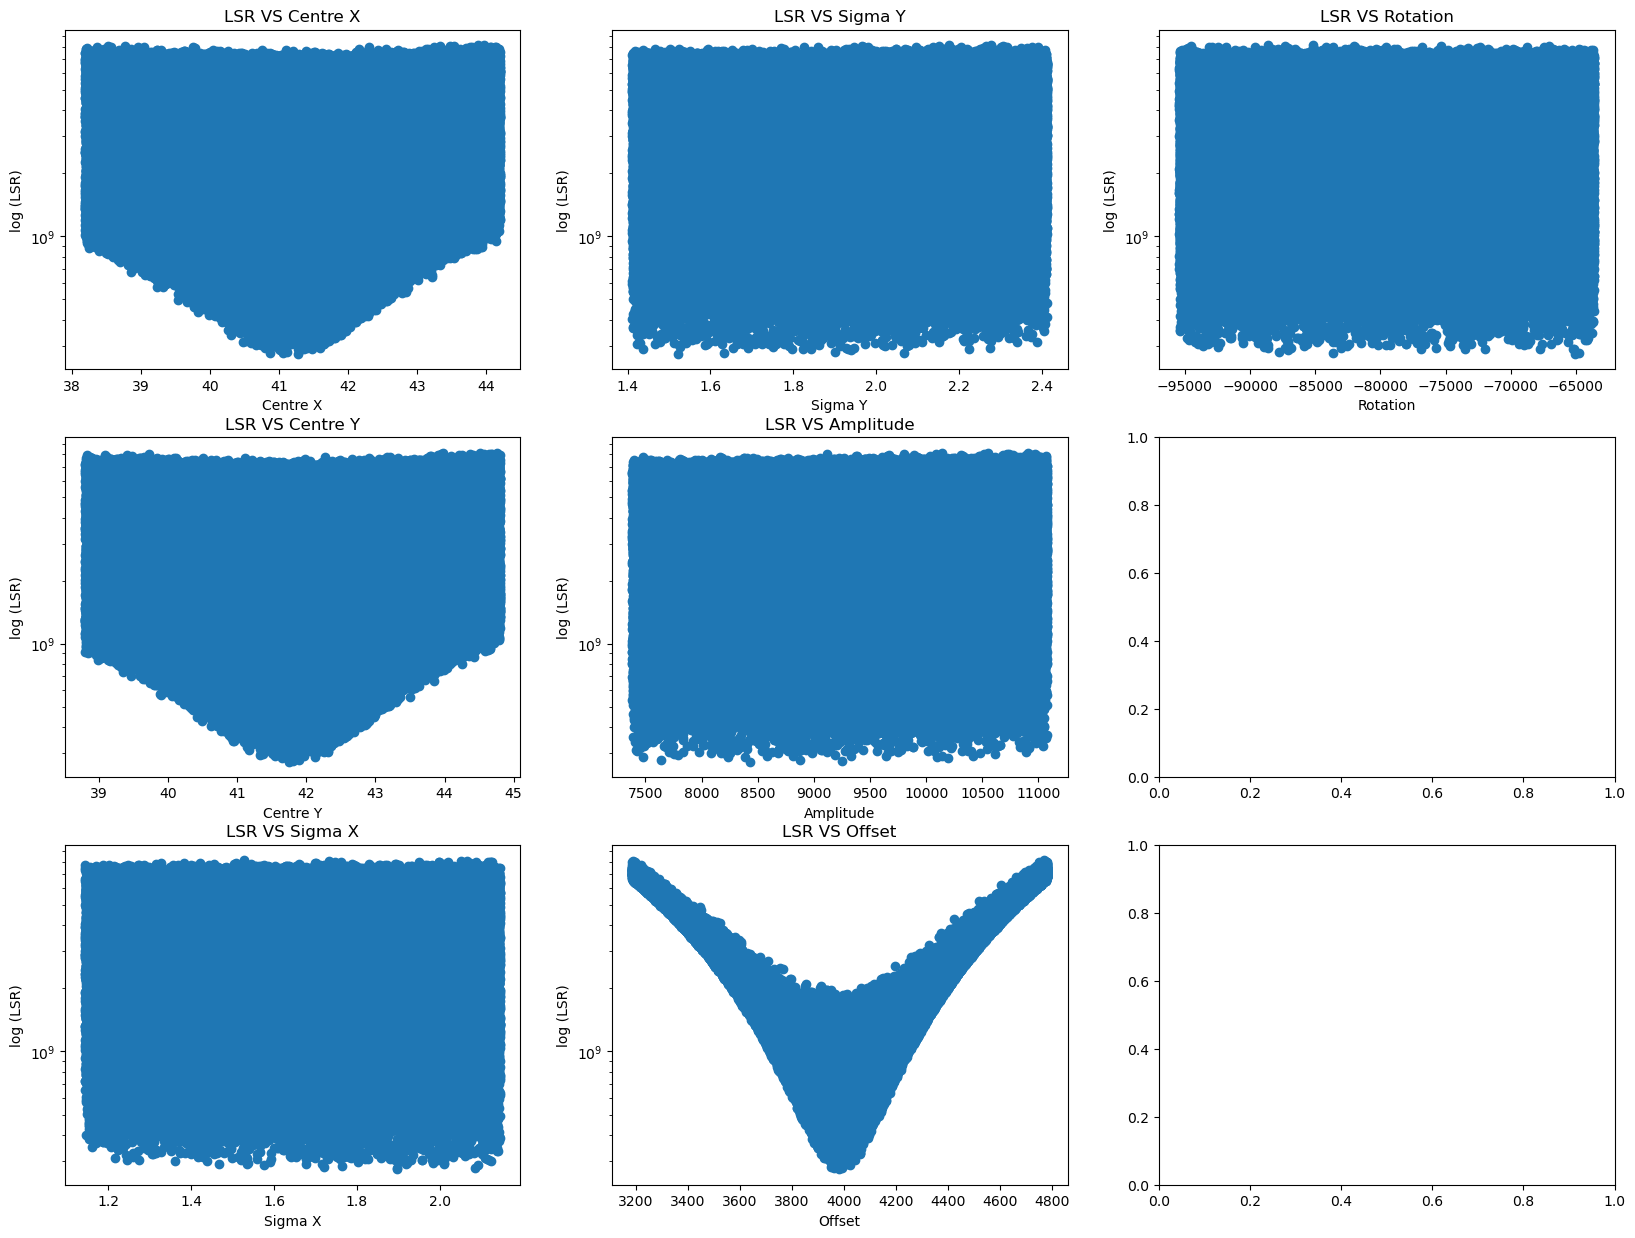

In [79]:
#parameters VS LSR subplots
fig, ax = plt.subplots(3,3, figsize=(20,15))
ax[0,0].scatter(mux_mc, LSR_mc)
ax[0,0].set_yscale('log')
ax[0,0].set_title ('LSR VS Centre X')
ax[0,0].set_xlabel ('Centre X')
ax[0,0].set_ylabel ('log (LSR)')

ax[1,0].scatter(muy_mc, LSR_mc)
ax[1,0].set_yscale('log')
ax[1,0].set_title ('LSR VS Centre Y')
ax[1,0].set_xlabel ('Centre Y')
ax[1,0].set_ylabel ('log (LSR)')

ax[2,0].scatter(sigmax_mc, LSR_mc)
ax[2,0].set_yscale('log')
ax[2,0].set_title ('LSR VS Sigma X')
ax[2,0].set_xlabel ('Sigma X')
ax[2,0].set_ylabel ('log (LSR)')

ax[0,1].scatter(sigmay_mc, LSR_mc)
ax[0,1].set_yscale('log')
ax[0,1].set_title ('LSR VS Sigma Y')
ax[0,1].set_xlabel ('Sigma Y')
ax[0,1].set_ylabel ('log (LSR)')

ax[1,1].scatter(amplitude_mc, LSR_mc)
ax[1,1].set_yscale('log')
ax[1,1].set_title ('LSR VS Amplitude')
ax[1,1].set_xlabel ('Amplitude')
ax[1,1].set_ylabel ('log (LSR)')

ax[2,1].scatter(offset_mc, LSR_mc)
ax[2,1].set_yscale('log')
ax[2,1].set_title ('LSR VS Offset')
ax[2,1].set_xlabel ('Offset')
ax[2,1].set_ylabel ('log (LSR)')

ax[0,2].scatter(rotation_mc, LSR_mc)
ax[0,2].set_yscale('log')
ax[0,2].set_title ('LSR VS Rotation')
ax[0,2].set_xlabel ('Rotation')
ax[0,2].set_ylabel ('log (LSR)')


We see that the offset currently contributes the most to the minimum value of the LSR through the following distributions obtained. Based on this we can now try varrying our ranges for the random parameter estimation performed by the MC simulations to obtain more uniform distributions of the LSR.

<div class="alert alert-success">
At this point you could simply ask which values of each parameter correspond to the minimum LSR (which is often what we'd do if acting blindly on a minimization algorithm. Here instead we can decide to analyse the distributions and repeat the process of the last two cells, by copy/pasting these below and re-running them having adjusted the uniform distribution ranges in a way that will bring us closer to a better fit according to the LSR distribution dependencies. 
    
NOTE: You don't have to, but given some of the behaviour of the residuals and to optimize the fit, you can choose to use a different distribution like a "normal" one by using <code> random.normal </code> providing mean and standard deviation, this allows you to focus on the region you might think is more likely rather than "spending time" in less efficient regions... however the price to pay is that your range is not actually contained in a given interval (this can be a benefit or a hindrance).
</div>

Text(0, 0.5, 'log (LSR)')

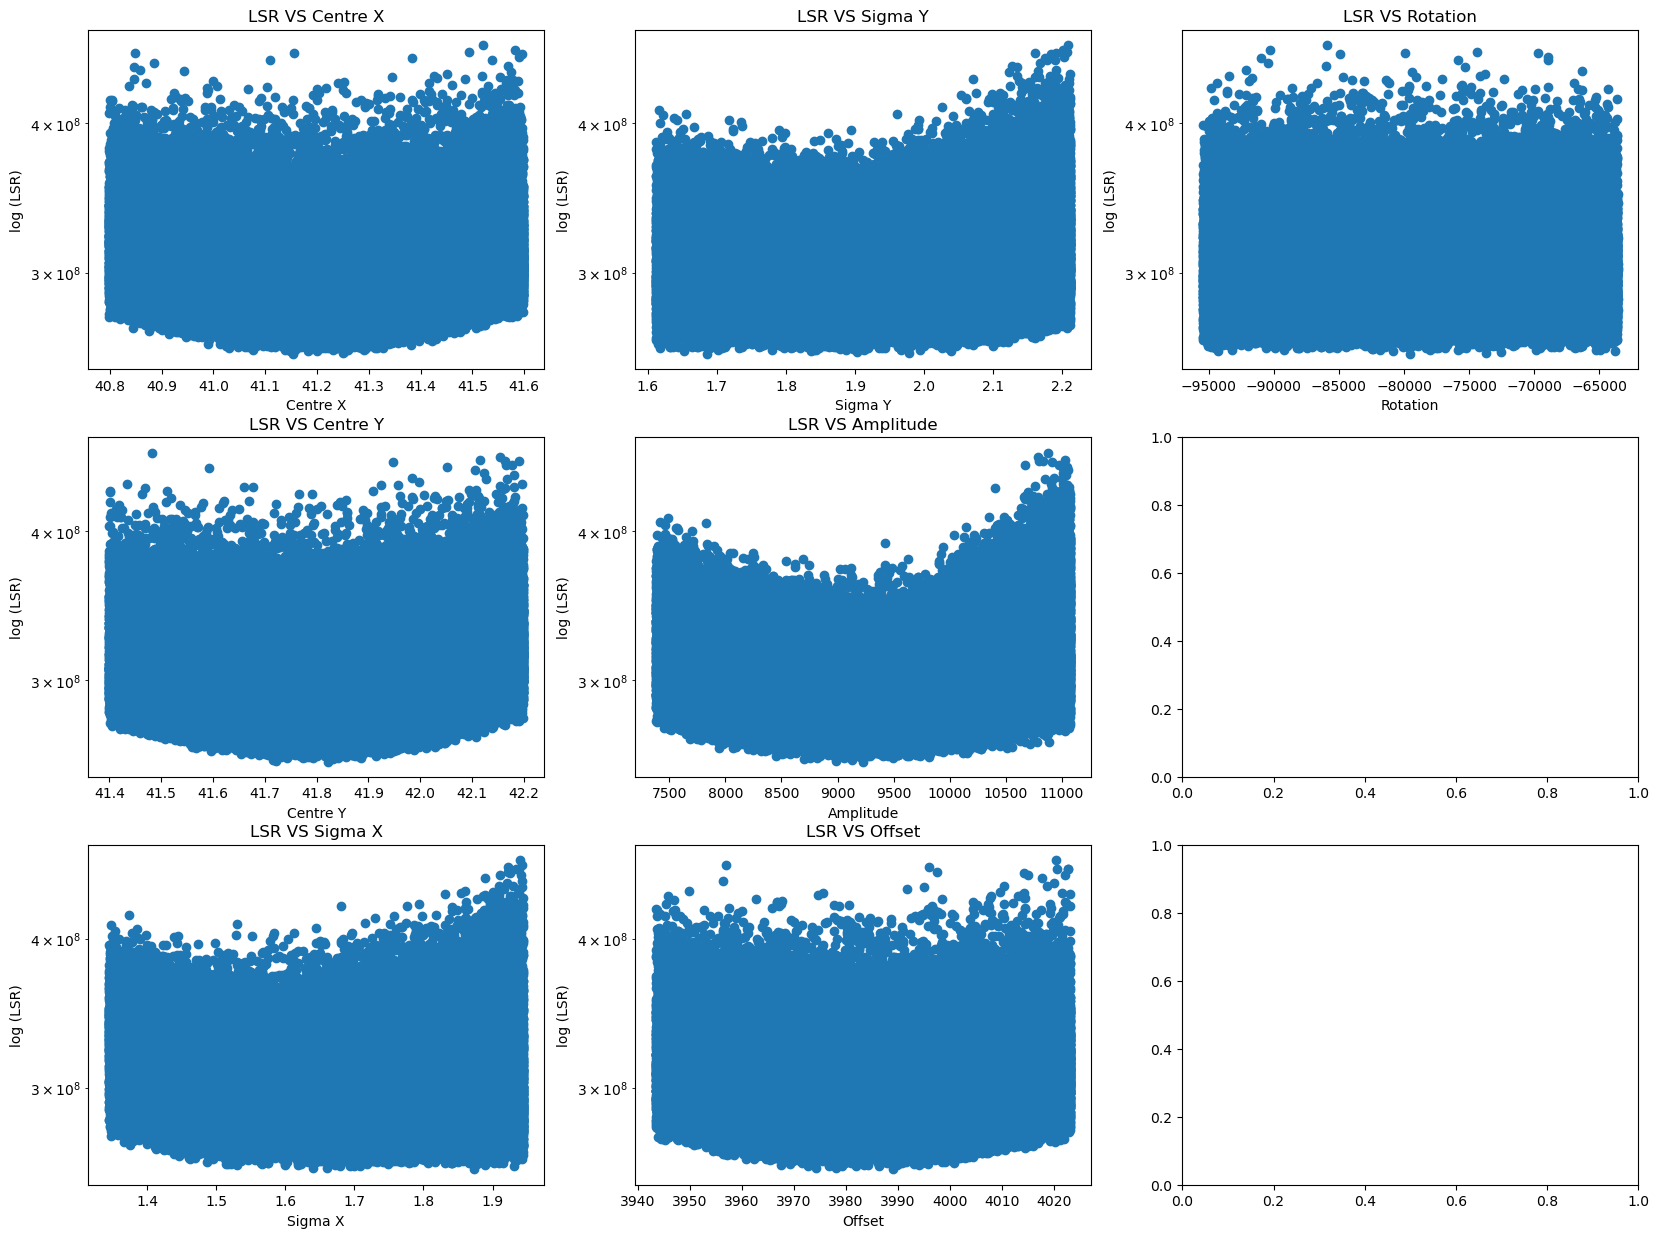

In [83]:
#monte carlo simulations n = 10000
n = 100000

#define empty arrays
mux_mc =np.array([]) #zoom in
muy_mc = np.array([]) #zoom in
sigmax_mc = np.array([]) #zoom out
sigmay_mc = np.array([]) #zoom out
amplitude_mc = np.array([]) 
offset_mc = np.array([])
rotation_mc = np.array ([])
LSR_mc = np.array ([])

#loop
for x in range (n):
    mux_run = random.uniform(m0x_fit - 0.4, m0x_fit + 0.4)
    muy_run = random.uniform(m0y_fit - 0.4, m0y_fit + 0.4)
    sigmax_run = random.uniform(sigmax_fit - 0.3, sigmax_fit + 0.3)
    sigmay_run = random.uniform(sigmay_fit - 0.3, sigmay_fit + 0.3)
    amplitude_run = random.uniform(0.8 * amplitude_fit, 1.2* amplitude_fit) 
    offset_run = random.uniform(0.99 * offset_fit, 1.01* offset_fit) 
    rotation_run = random.uniform(0.8 * rotation_fit, 1.2* rotation_fit) 

    #gaussian
    mc_gauss = Gauss2D(xy1d, mux_run, muy_run, sigmax_run, sigmay_run, amplitude_run, offset_run, rotation_run)

    #lSR
    LSR_run =np.sum((unp_subset - mc_gauss)**2)
    
    #append
    mux_mc = np.append(mux_mc, mux_run)
    muy_mc = np.append(muy_mc, muy_run)
    sigmax_mc = np.append(sigmax_mc, sigmax_run)
    sigmay_mc = np.append(sigmay_mc, sigmay_run)
    amplitude_mc =np.append(amplitude_mc, amplitude_run)
    offset_mc = np.append (offset_mc, offset_run)
    rotation_mc = np.append (rotation_mc, rotation_run)
    LSR_mc = np.append (LSR_mc, LSR_run)
    

#parameters VS LSR subplots
fig, ax = plt.subplots(3,3, figsize=(20,15))
ax[0,0].scatter(mux_mc, LSR_mc)
ax[0,0].set_yscale('log')
ax[0,0].set_title ('LSR VS Centre X')
ax[0,0].set_xlabel ('Centre X')
ax[0,0].set_ylabel ('log (LSR)')

ax[1,0].scatter(muy_mc, LSR_mc)
ax[1,0].set_yscale('log')
ax[1,0].set_title ('LSR VS Centre Y')
ax[1,0].set_xlabel ('Centre Y')
ax[1,0].set_ylabel ('log (LSR)')

ax[2,0].scatter(sigmax_mc, LSR_mc)
ax[2,0].set_yscale('log')
ax[2,0].set_title ('LSR VS Sigma X')
ax[2,0].set_xlabel ('Sigma X')
ax[2,0].set_ylabel ('log (LSR)')

ax[0,1].scatter(sigmay_mc, LSR_mc)
ax[0,1].set_yscale('log')
ax[0,1].set_title ('LSR VS Sigma Y')
ax[0,1].set_xlabel ('Sigma Y')
ax[0,1].set_ylabel ('log (LSR)')

ax[1,1].scatter(amplitude_mc, LSR_mc)
ax[1,1].set_yscale('log')
ax[1,1].set_title ('LSR VS Amplitude')
ax[1,1].set_xlabel ('Amplitude')
ax[1,1].set_ylabel ('log (LSR)')

ax[2,1].scatter(offset_mc, LSR_mc)
ax[2,1].set_yscale('log')
ax[2,1].set_title ('LSR VS Offset')
ax[2,1].set_xlabel ('Offset')
ax[2,1].set_ylabel ('log (LSR)')

ax[0,2].scatter(rotation_mc, LSR_mc)
ax[0,2].set_yscale('log')
ax[0,2].set_title ('LSR VS Rotation')
ax[0,2].set_xlabel ('Rotation')
ax[0,2].set_ylabel ('log (LSR)')


We see that after varrying our ranges appropriately we end up with more uniform distributions (apart from the rotation, but that is not at the centre of this investigation), hopefully allowing us to gain a better estimate of the minimum of LSR for each parameter. 

<div class="alert alert-success">
After one or more iterations, you can take the values which produce the minimum LSR and create the relevant fitted psf and then produce the same image+contour you did above and surface of residuals to compare with the automated result.
</div>

Using np.min() to find the minimum value of the LSR for each fit parameter and subsequently using np.where to find what value of the parameter contributes to the minimum value, we can obtain new values that we can then comapre the to the SciPy fit values. 

In [88]:
#finding minimum LSR and its index
LSR_min_index = np.argmin(LSR_mc)

#finding corresponding values through indexing 
min_mux = mux_mc[LSR_min_index]
min_muy = muy_mc[LSR_min_index]
min_sigmax = sigmax_mc[LSR_min_index]
min_sigmay = sigmay_mc[LSR_min_index]
min_amplitude = amplitude_mc[LSR_min_index]
min_offset = offset_mc[LSR_min_index]
min_rotation = rotation_mc[LSR_min_index]

#print our MC obtained values 
print (f"X-centre via MC: {min_mux:.3f}")
print (f"Y-centre via MC: {min_muy:.3f}")
print (f"Sigma x via MC: {min_sigmax:.3f}")
print (f"Sigma y via MC: {min_sigmay:.3f}")
print (f"Amplitude via MC: {min_amplitude:.3f}")
print (f"Offset via MC: {min_offset:.3f}")
print (f"Rotation via MC: {min_rotation:.3f}")


X-centre via MC: 41.153
Y-centre via MC: 41.822
Sigma x via MC: 1.873
Sigma y via MC: 1.686
Amplitude via MC: 9227.991
Offset via MC: 3989.050
Rotation via MC: -79520.456


In [90]:
#reprint our SciPy fit values for comparison:
print (f"The x-centre of the SciPy fit is {m0x_fit:.3f} ± {m0x_err:.3f}")
print (f"The y-centre of the SciPy fit is {m0y_fit:.3f} ± {m0y_err:.3f}")
print (f"The sigma X of the SciPy fit is {sigmax_fit:.3f} ± {sigmax_err:.3f}")
print (f"The sigma Y of the SciPy fit is {sigmay_fit:.3f} ± {sigmay_err:.3f}")
print (f"The amplitude of the SciPy fit is {amplitude_fit:.3f} ± {amplitude_err:.3f}")
print (f"The off-set of the SciPy fit is {offset_fit:.3f} ± {offset_err:.3f}")
print (f"The rotation of the SciPy fit is {rotation_fit:.3f} ± { rotation_err:.3f}")

The x-centre of the SciPy fit is 41.198 ± 0.014
The y-centre of the SciPy fit is 41.799 ± 0.014
The sigma X of the SciPy fit is 1.645 ± 0.013
The sigma Y of the SciPy fit is 1.912 ± 0.015
The amplitude of the SciPy fit is 9228.920 ± 71.885
The off-set of the SciPy fit is 3983.369 ± 1.604
The rotation of the SciPy fit is -79519.068 ± 0.036


We have sucessfully found a new set of parameters for our Gaussian fit of our chosen source. Notice that the deviations from our SciPy fit are small and most noteable in the sigma X, sigma Y, rotation and amplitude (although that still falls withing errors). Let us repeat the process from the previous section and plot the contour onto our image:

Text(0, 0.5, 'Y')

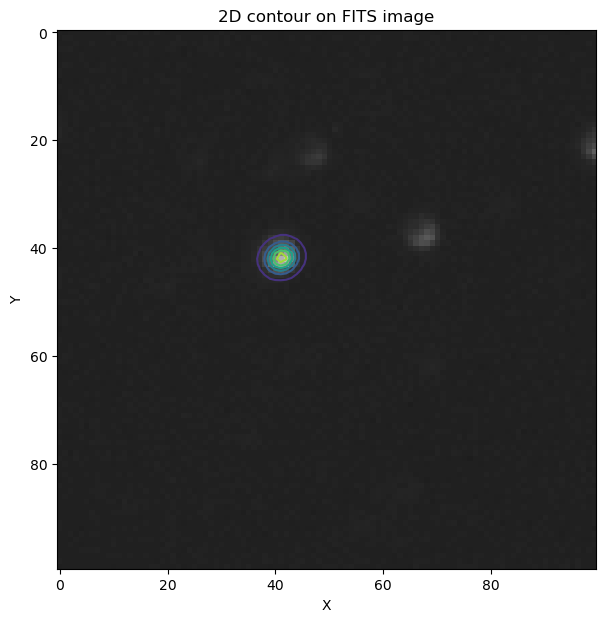

In [93]:
#apply MC fit values to gaussian 
MC_fit1d = Gauss2D (xy1d, min_mux, min_muy, min_sigmax, min_sigmay, min_amplitude, min_offset, min_rotation)
MC_fit = MC_fit1d.reshape(size,size)

#plot contour on FITS image using MC parameters 
#plot the contour
plt.figure(figsize=(14,7))
plt.imshow(star_section, cmap = 'gray', vmin = 1865, vmax = 17944 )
plt.contour(xx, yy, MC_fit, origin = 'lower')
plt.title ("2D contour on FITS image")
plt.xlabel("X")
plt.ylabel ("Y")


With a 2D contour sucessully plotted, let us now plot a 3D contour plot of both of these fits:

Text(0.5, 0, 'Z-axis')

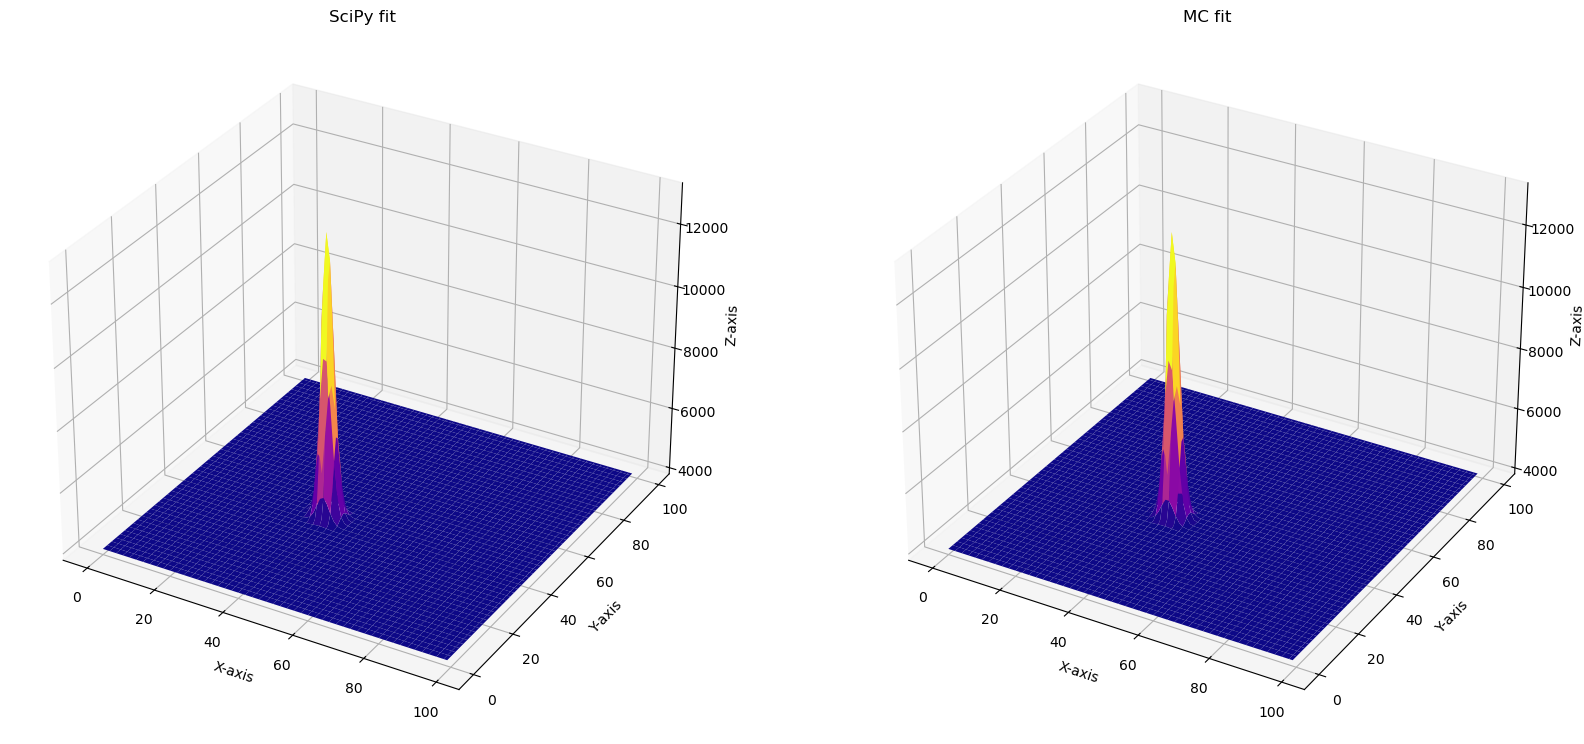

In [96]:
#creating contour plots 
figure, axis = plt.subplots(1,2, figsize=(20,10), subplot_kw={"projection": "3d"})


#Scipy
axis[0].plot_surface (xx, yy, Z_fit, cmap=cm.plasma)
axis[0].set_title ("SciPy fit")
axis[0].set_xlabel('X-axis')
axis[0].set_ylabel('Y-axis')
axis[0].set_zlabel('Z-axis')

#MC
axis[1].plot_surface (xx, yy, MC_fit, cmap=cm.plasma)
axis[1].set_title ("MC fit")
axis[1].set_xlabel('X-axis')
axis[1].set_ylabel('Y-axis')
axis[1].set_zlabel('Z-axis')



Upon inspection we see that these fits look pretty similar, with a sharp gaussian peak at the center representing the star. Let us now show a variation of subtracted contour plots so we can further investigate these fitting methods. The 3D contour plot we will plot are as follows:
- SciPy fit  subtracted from FITS image  = we alreaady did this in a previous section
- MC simulations subtracted from FITS image
- MC simulation subtracted from SciPy fit 

Text(0.5, 0, 'Z-axis')

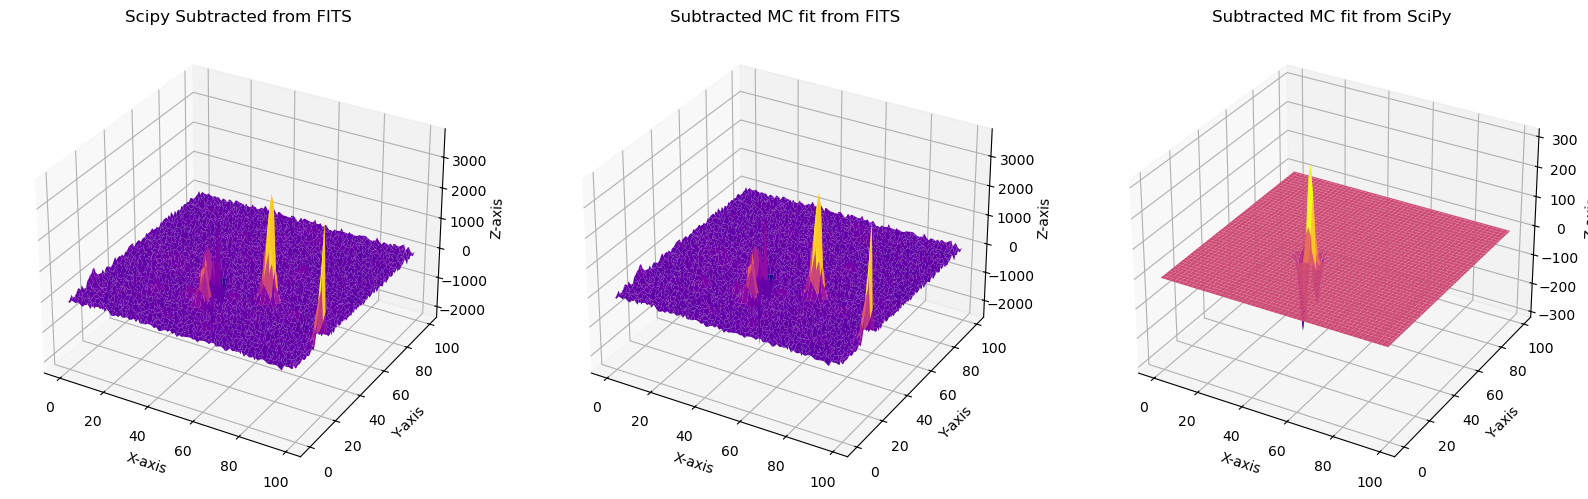

In [99]:
#creating subtracted 3D contour plots 
figure, axis = plt.subplots(1,3, figsize=(20,10), subplot_kw={"projection": "3d"})

#subtracting SciPy from FITS (as done above)
axis[0].plot_surface (xx, yy, z_subtracted, cmap=cm.plasma)
axis[0].set_title ("Scipy Subtracted from FITS")
axis[0].set_xlabel('X-axis')
axis[0].set_ylabel('Y-axis')
axis[0].set_zlabel('Z-axis')

#subtracting MC from SciPy fit 
subtractedmc = star_section - MC_fit
axis[1].plot_surface (xx, yy, subtractedmc, cmap=cm.plasma)
axis[1].set_title ("Subtracted MC fit from FITS")
axis[1].set_xlabel('X-axis')
axis[1].set_ylabel('Y-axis')
axis[1].set_zlabel('Z-axis')


#subtracting MC from SciPy fit 
subtracted = Z_fit - MC_fit
axis[2].plot_surface (xx, yy, subtracted, cmap=cm.plasma)
axis[2].set_title ("Subtracted MC fit from SciPy")
axis[2].set_xlabel('X-axis')
axis[2].set_ylabel('Y-axis')
axis[2].set_zlabel('Z-axis')

We have obtained the subtracted 3D contour which can now help us compare these two methods of obtaining fit parameters. The first two subplots indicate that the two methods of fitting seem almost equivalent as when we subtract them from the FITS image we obtain a similar distribution that depicts the three faint stars in our chosen section of the sky and some noise. Nevertheless, we can go a step further and look at our third plot which gives the difference between the SciPy fit and the MC simulation. As one could infer from computing the coefficient values alone, these two methods are not identical and do yield slightly different results. After the MC subtraction we are still left with a small residual in the SciPy plot, which could inidcate that the MC simulation does not fully account for the star signal. However, the height of the residual peak is only around 300 where as the max height peak is around 9000, making it a ~3% difference. 

## Conclusion


To summarise, in this task, we investigated fitting a 2D Gaussian function to a chosen source in a FITS image. After familirising ourseleves with the methods of 2D function fitting, we used the SciPy "scipy. optimise.curve_fit" to find values of x-centre, y-centre, sigma x, sigma y, amplitude, offset and rotation for a 2D Gaussian fit for our chosen star. By plotting 2D and 3D contour plots, we confirmed the validity of this method as the fit matched the star signal appropriately.

We then proceeded to find the mentioned fit parameters using an alternative method: Monte Carlo simulations. By running 100000 MC simulations and allowing a chosen range for the algorithm to randomly choose the fit values from, we created a new set of simulated parameters. To evaluate their goodness, we computed the least squares residual for each MC iteration and plotted the dependence of each fit parameter on the LSR. Upon visualisation, we saw that some of our fit parameters (mostly offset and x-centre & y-centre) were dominating the LSR. Aiming to gain an LSR that is not biased towards a certain fit parameter, we ran our MC simulations again and changed the ranges appropriately until our subplots looked uniform. With suitable outputs of our MC simulations, we found a new set of fit parameters for our Gaussian of the source by finding the parameter value corresponding to the minimum LSR for each subplot. 

Our two sets of fit parameters for the Gaussian allow us to compare the two methods explored in this task. Plotting subtracted subplots allowed us to see that the fitting of the source is almost the same. There seems to be a ~3% difference between the fits, which can be inferred from subtracting our MC fit from the SciPy one. This indicates a small centre offset and perhaps slight numerical differences in the optimisation precisions. As results are so similar, choosing one method over another seems to be hard to argue. While the MC simulations are less sensitive to initial guesses, it seems that SciPy does provide a slightly better estimate for the overall star signal. An extension of this investigation could include fitting a different PSF profile (Airy disk, Moffat profile) to our star and running both methods again to see if one proves to be more suitable than the other. Additionally, we have not obtained error values in our MC simulations, so for a more rigorous scientific approach, we could run an MCMC simulation to gain an idea about the errors, which would give us better ground to compare the two methods. 

## References

[1] Gaussian function. [online] Wikipedia [Accessed 12 February 2026]. Available from: https://en.wikipedia.org/wiki/Gaussian_function